In [204]:
import numpy as np
import pandas as pd
import random
import copy
import matplotlib.pyplot as plt

In [205]:
honey = pd.read_csv('honey.csv', sep=";")
weather = pd.read_csv('df_weekly_2019_2025.csv')
beehives = pd.read_csv('ule.csv', sep=";")

In [206]:
df = pd.merge(honey, weather, on=["year", "week"], how="inner")

In [207]:
df = pd.merge(df, beehives, on="year", how="inner")

In [208]:
df.head()

,year,week,honey,harvest,month,temp,wspd,prcp,pres,beehive
0,2019,30,66.0,1,7,18.468962,2.068542,0.125877,949.43176,92
1,2019,32,55.0,1,8,19.387705,1.972191,0.171244,948.63810,92
2,2019,33,134.0,2,8,16.821316,1.924085,0.108202,949.98334,92
3,2019,34,72.0,1,8,18.534908,1.906017,0.032221,957.32385,92
4,2019,35,59.0,1,8,20.535137,1.664818,0.082062,955.53265,92


Zakładamy, że wydajność pszczółki będzie zależeć od temperatury, prędkości wiatru, ilości opadu atmosferycznego, ciśnienia atmosferycznego oraz jej bazowej wydajności.

In [209]:
# parametry do późniejszej optymalizacji
params = {
    "temp_low": 10,
    "temp_high": 30,
    "temp_slope": 2.3,

    "wind_penalty": 0.3,

    "rain_penalty": 3.9,
    "rain_window": 20,

    "pres_penalty": 0.02,

    "base_efficiency": 1.0
}

In [210]:
def bee_efficiency(temp, wspd, prcp, pres, p):
    
    # jeżeli za ciepło lub za zimno - nie lata
    # załużmy, że optymalna temperatura to 14 stopnie, a efektywność spada liniowo w miarę oddalania się od tej wartości
    if temp < p["temp_low"]:
        temp_eff = 0
    elif temp > p["temp_high"]:
        temp_eff = 0
    else:
        temp_eff = 1 - abs(temp - 14) / p["temp_slope"]
        temp_eff = max(0, temp_eff)

    # przy silnym wietrze pszczoły nie latają, zakładamy liniowy spadek efektywności wraz ze wzrostem prędkości wiatru
    wind_eff = max(0, 1 - p["wind_penalty"] * wspd)

    # taka sama logika przy opadach
    rain_eff = max(0, 1 - p["rain_penalty"] * prcp)

    pres_eff = max(0, 1 - p["pres_penalty"] * pres)

    return temp_eff * wind_eff * rain_eff * pres_eff

In [211]:
def simulate_honey(row, p):

    eff = bee_efficiency(
        row["temp"],
        row["wspd"],
        row["prcp"],
        row["pres"],
        p
    )

    # bazowa produkcja dla kolonii
    honey = (
        row["beehive"] *
        eff *
        p["base_efficiency"] *
        row["harvest"]
    )

    return honey

In [212]:
def loss(params_dict, df):

    preds = []

    for _, row in df.iterrows():
        preds.append(simulate_honey(row, params_dict))

    preds = np.array(preds)
    rmse = np.sqrt(np.mean((df["honey"].values - preds)**2))

    return rmse

In [213]:
bee = {
    "temp_low": 11,
    "temp_high": 31,
    "temp_slope": 2.1,
    "wind_penalty": 0.25,
    "rain_penalty": 4.2,
    "pres_penalty": 0.015,
    "base_efficiency": 1.05
}

In [214]:
def fitness(bee_params):
    return loss(bee_params, df)

In [215]:
def random_bee():
    return {
        "temp_low": random.uniform(6, 10),
        "temp_high": random.uniform(20, 25),
        "temp_slope": random.uniform(0.5, 5.0),
        "wind_penalty": random.uniform(0.0, 1.0),
        "rain_penalty": random.uniform(0.0, 8.0),
        "pres_penalty": random.uniform(0.0, 0.05),
        "base_efficiency": random.uniform(0.5, 1.5)
    }

population = [random_bee() for _ in range(100)]

def mutate(bee):
    new_bee = copy.deepcopy(bee)

    key = random.choice(list(bee.keys()))
    new_bee[key] += random.uniform(-0.2, 0.2)

    return new_bee

def run_opt(iterations=100):

    global population

    for _ in range(iterations):

        for i in range(len(population)):

            candidate = mutate(population[i])

            if fitness(candidate) < fitness(population[i]):
                population[i] = candidate

    return min(population, key=fitness)

Algorytm ABC - analogia do rodzajów pszczółek

Zakładamy, że kolonia składa się z 3 rodzajów pszczółek; employed, onlookers i scouts. Reprezentują one etapy optymalizacji. Na początku employed bees - każda pszczoła (czyli jedno rozwiązanie), próbuje dzięki sąsiadowi je lekko zminić. Jak sie uda, to zmienia swoje parametry. Onlookers bees - wybierają rozwiązanie z większym prawdopodobieństawem i próbują tak samo poprawić swoje. Scout bees - jeżeli nie poprawia się rozwiązanie przez jakiś ustalony limit iteracji, zastępuje go losowe inne.

chybaXD

In [216]:
param_bounds = {
    "temp_low": (6, 12),
    "temp_high": (25, 35),
    "temp_slope": (0.5, 5.0),
    "wind_penalty": (0.0, 1.0),
    "rain_penalty": (0.0, 8.0),
    "pres_penalty": (0.0, 0.05),
    "base_efficiency": (0.5, 1.5)
}


def random_bee():
    return {k: random.uniform(low, high) for k, (low, high) in param_bounds.items()}

# jezeli wyjdzie poza zakres, aby byla we wczesniej ustalonym zakresie
def repair_bee(bee):
    return {k: min(max(bee[k], low), high) for k, (low, high) in param_bounds.items()}

# na podstawie dwoch pszczolek tworzymi jego sasiada
def neighbor_bee(current, other):
    best = current.copy()
    # losowy parametr do zminay
    key = random.choice(list(param_bounds.keys()))
    phi = random.uniform(-1, 1)
    best[key] = current[key] + phi * (current[key] - other[key])
    return repair_bee(best)

# lepsza pszczołka ma większe szanse być wybrana
def loss_to_probability(losses):
    fitness_values = [1.0 / (1.0 + l) for l in losses]
    total = sum(fitness_values)
    return [f / total for f in fitness_values]


def run_abc(iterations=100, colony_size=30, limit=50):
    bees = [random_bee() for _ in range(colony_size)]
    losses = [loss(bee, df) for bee in bees]
    # ile razy pszczółka sie nie poprawiła
    trials = [0] * colony_size

    best_index = int(np.argmin(losses))
    best_bee = bees[best_index]
    best_loss = losses[best_index]

    for _ in range(iterations):
        for i in range(colony_size):
            # losowy wybór sąsiada
            k = random.choice([j for j in range(colony_size) if j != i])
            candidate = neighbor_bee(bees[i], bees[k])
            candidate_loss = loss(candidate, df)
            if candidate_loss < losses[i]:
                bees[i], losses[i] = candidate, candidate_loss
                trials[i] = 0
            else:
                trials[i] += 1

        probabilities = loss_to_probability(losses)
        t = 0
        i = 0
        while t < colony_size:
            if random.random() < probabilities[i]:
                k = random.choice([j for j in range(colony_size) if j != i])
                candidate = neighbor_bee(bees[i], bees[k])
                candidate_loss = loss(candidate, df)
                if candidate_loss < losses[i]:
                    bees[i], losses[i] = candidate, candidate_loss
                    trials[i] = 0
                else:
                    trials[i] += 1
                t += 1
            i = (i + 1) % colony_size

        # zmiana pszczółki, która się nie poprawiła przez limit iteracji
        for i in range(colony_size):
            if trials[i] > limit:
                bees[i] = random_bee()
                losses[i] = loss(bees[i], df)
                trials[i] = 0

        current_best_index = int(np.argmin(losses))
        current_best_loss = losses[current_best_index]
        if current_best_loss < best_loss:
            best_loss = current_best_loss
            best_bee = bees[current_best_index]

    return best_bee

In [217]:
# wynik symulacji dla bazowych prametrów

df['predicted_honey'] = df.apply(lambda row: simulate_honey(row, bee), axis=1)
rmse = np.sqrt(np.mean((df['honey'] - df['predicted_honey'])**2))
print(f'RMSE = {rmse:.4f}')
df[['year', 'week', 'honey', 'predicted_honey']].head(15)

RMSE = 158.1202


,year,week,honey,predicted_honey
0,2019,30,66.0,0.0
1,2019,32,55.0,0.0
2,2019,33,134.0,0.0
3,2019,34,72.0,0.0
4,2019,35,59.0,0.0
5,2019,35,59.0,0.0
6,2019,36,147.0,0.0
7,2020,26,410.9,0.0
8,2020,29,63.0,0.0
9,2020,30,140.0,0.0


In [ ]:
# optymalizacja parametrów run_opt

best_bee = run_opt(iterations=100)
best_rmse = loss(best_bee, df)
print('Najlepsze parametry:')
print(best_bee)
print(f'RMSE = {best_rmse:.4f}')

df['predicted_honey_best'] = df.apply(lambda row: simulate_honey(row, best_bee), axis=1)
df[['year', 'week', 'honey', 'predicted_honey_best']].head(15)

Najlepsze parametry:
{'temp_low': 8.17112934608593, 'temp_high': 24.337145153818632, 'temp_slope': 5.301890982407951, 'wind_penalty': 0.1645481455444996, 'rain_penalty': 0.8576788560871693, 'pres_penalty': -0.006547666532866606, 'base_efficiency': 0.6309462609552432}
RMSE = 120.9487


,year,week,honey,predicted_honey_best
0,2019,30,66.0,38.722962
1,2019,32,55.0,0.000000
2,2019,33,134.0,243.138191
3,2019,34,72.0,40.733421
4,2019,35,59.0,0.000000
5,2019,35,59.0,0.000000
6,2019,36,147.0,185.548830
7,2020,26,410.9,51.250172
8,2020,29,63.0,184.671062
9,2020,30,140.0,67.805837


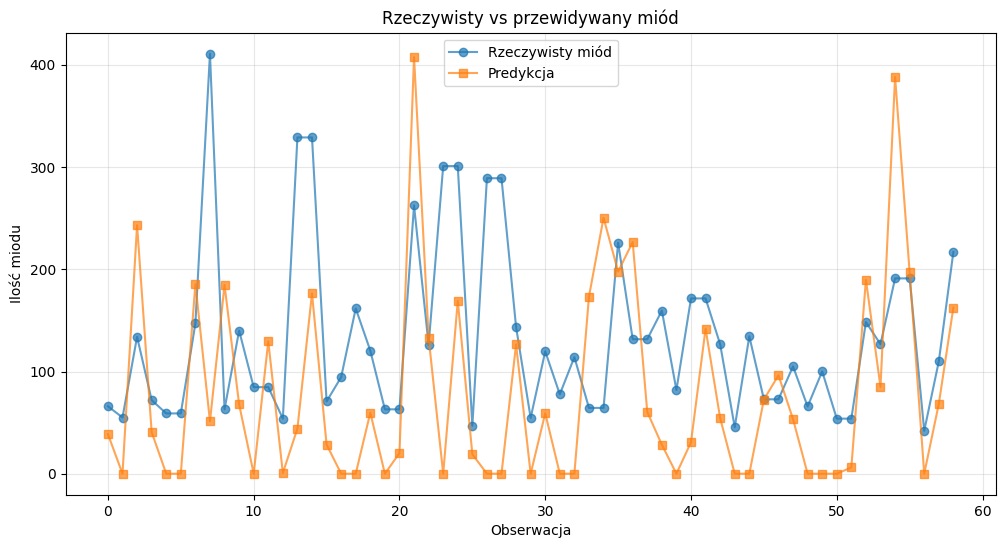

In [219]:
plt.figure(figsize=(12, 6))
plt.plot(df["honey"].values, label="Rzeczywisty miód", marker='o', alpha=0.7)
plt.plot(df["predicted_honey_best"].values, label="Predykcja", marker='s', alpha=0.7)
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.xlabel("Obserwacja")
plt.ylabel("Ilość miodu")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# najlepszy wynik z run_opt

{'temp_low': 9.160728007762975, 'temp_high': 24.49404711270679, 'temp_slope': 43.35895073491914, 'wind_penalty': -0.3670792426740751, 'rain_penalty': -1.2448320056154039, 'pres_penalty': -0.00013839921508588746, 'base_efficiency': 0.4877893795676532}
RMSE = 68.1048

In [221]:
{'temp_low': 9.160728007762975, 'temp_high': 24.49404711270679, 'temp_slope': 19.16652515079757, 'wind_penalty': -0.23988570198499704, 'rain_penalty': -1.0159632323437868, 'pres_penalty': -0.00013839921508588746, 'base_efficiency': 0.6871523057723211}
RMSE = 70.3003

In [223]:
# optymalizacja parametrów algorytmem abc

best_bee = run_abc(iterations=500, colony_size=100, limit=50)
best_rmse = loss(best_bee, df)
print('Najlepsze parametry:')
print(best_bee)
print(f'RMSE = {best_rmse:.4f}')

df['predicted_honey_best'] = df.apply(lambda row: simulate_honey(row, best_bee), axis=1)
df[['year', 'week', 'honey', 'predicted_honey_best']].head(15)

Najlepsze parametry:
{'temp_low': 11.732807733974068, 'temp_high': 34.540019961371236, 'temp_slope': 5.0, 'wind_penalty': 0.0, 'rain_penalty': 0.0, 'pres_penalty': 0.0, 'base_efficiency': 1.5}
RMSE = 120.5781


,year,week,honey,predicted_honey_best
0,2019,30,66.0,14.656649
1,2019,32,55.0,0.000000
2,2019,33,134.0,120.263357
3,2019,34,72.0,12.836539
4,2019,35,59.0,0.000000
5,2019,35,59.0,0.000000
6,2019,36,147.0,121.844285
7,2020,26,410.9,34.801723
8,2020,29,63.0,106.216304
9,2020,30,140.0,26.903724


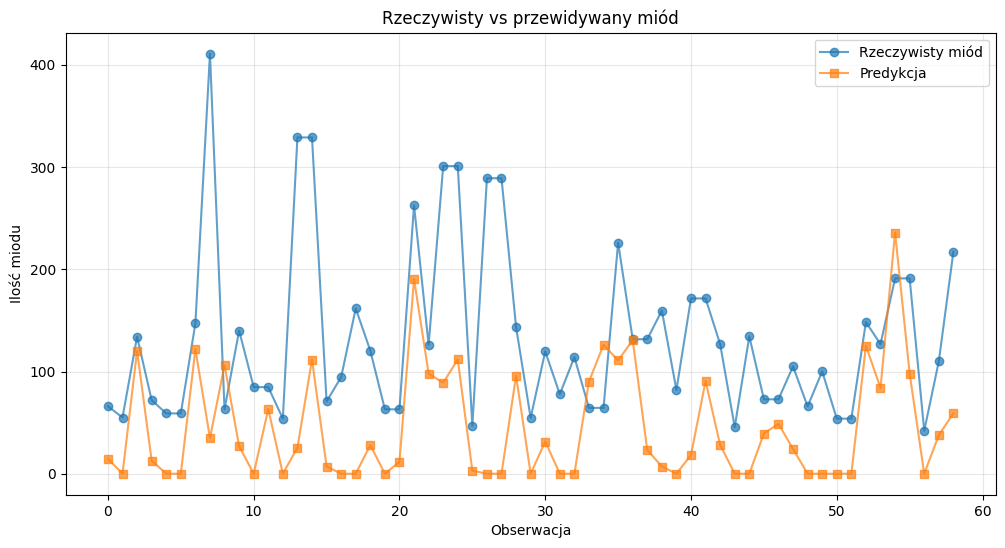

In [224]:
plt.figure(figsize=(12, 6))
plt.plot(df["honey"].values, label="Rzeczywisty miód", marker='o', alpha=0.7)
plt.plot(df["predicted_honey_best"].values, label="Predykcja", marker='s', alpha=0.7)
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.xlabel("Obserwacja")
plt.ylabel("Ilość miodu")
plt.grid(True, alpha=0.3)
plt.show()

Na kilka prób run_abc nie udało się uzyskać lepszego wyniku niż dzięki run_opt.